In [1]:
!pip install langgraph

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from typing import TypedDict
from langgraph.graph import StateGraph, START,END

In [3]:
class AgentState(TypedDict):
    message: str

In [8]:
def compliment(state: AgentState):
    state['message'] = state['message'] + ", you're doing an amazing job learning langgraph"
    return {"message":state["message"]}

In [9]:
graph = StateGraph(AgentState)

graph.add_node("compliment",compliment)
graph.set_entry_point("compliment")
graph.set_finish_point("compliment")

app = graph.compile()


In [10]:
app.invoke({"message":"sofiene"})

{'message': "sofiene, you're doing an amazing job learning langgraph"}

In [31]:
class AgentState(TypedDict):
    number1:int 
    number2:int
    number3:int
    number4:int
    operation1:str
    operation2:str
    finalnumber1:int
    finalnumber2:int

In [32]:
def router(state:AgentState):
    if state["operation1"] == "+":
        return "addition_operation"
    if state["operation1"] == "-":
        return "substract_operation"

def router2(state:AgentState):
    if state["operation2"] == "+":
        return "addition_operation"
    if state["operation2"] == "-":
        return "substract_operation"

In [33]:
def add_node(state:AgentState):
    state["finalnumber1"] = state['number1'] + state["number2"]
    return state

def substract_node(state:AgentState):
    state["finalnumber1"] = state['number1'] - state["number2"]
    return state



In [34]:
def add_node2(state:AgentState):
    state["finalnumber2"] = state['number3'] + state["number4"]
    return state

def substract_node2(state:AgentState):
    state["finalnumber2"] = state['number3'] - state["number4"]
    return state

In [35]:
builder = StateGraph(AgentState)

builder.add_node("router",lambda state:state)
builder.add_node("router2",lambda state:state)
builder.add_node("add_node",add_node)
builder.add_node("add_node2",add_node2)
builder.add_node("substract_node",substract_node)
builder.add_node("substract_node2",substract_node2)

builder.add_conditional_edges("router",router,{"addition_operation":"add_node","substract_operation":"substract_node"})
builder.add_conditional_edges("router2",router2,{"addition_operation":"add_node2","substract_operation":"substract_node2"})

builder.add_edge(START,"router")
builder.add_edge("add_node","router2")
builder.add_edge("substract_node","router2")
builder.add_edge("add_node2",END)
builder.add_edge("substract_node2",END)

graph = builder.compile()


In [36]:
graph.invoke({"number1":10,"number2":5,"number3":7,"number4":2,"operation1":"-","operation2":"-"})

{'number1': 10,
 'number2': 5,
 'number3': 7,
 'number4': 2,
 'operation1': '-',
 'operation2': '-',
 'finalnumber1': 5,
 'finalnumber2': 5}

In [39]:
from typing import List
import random
class AgentState(TypedDict):
    name:str
    number: List[int]
    counter:int

In [41]:
def greeting_node(state:AgentState):
    state["name"] = f"hi there, {state["name"]}"
    state["counter"] = 0

    return state

def random_node(state:AgentState):
    state["number"].append(random.randint(0,10))
    state["counter"] += 1
    return state

def should_continue(state:AgentState):
    if state["counter"]<5:
        return "loop"
    else:
        return "end"

In [ ]:
builder = StateGraph(AgentState)

builder.add_node("greeting",greeting_node)
builder.add_node("random",random_node)

builder.add_edge(START,"greeting")
builder.add_edge("greeting","random")
builder.add_conditional_edges("random",should_continue,{"loop":"random","end":END})

graph = builder.compile()

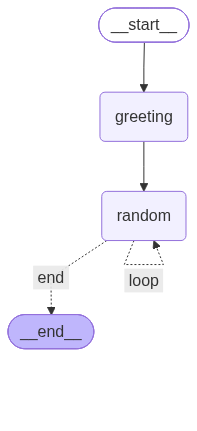

In [46]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [47]:
graph.invoke({"name":"sofiene","counter":-1,"number":[]})

{'name': 'hi there, sofiene', 'number': [4, 9, 8, 10, 8], 'counter': 5}

In [ ]:
class AgentState(TypedDict):
    player_name:str
    target_number: int
    guesses: List[int]
    hint: str
    attempts: int 
    lower_bound:int
    upper_bound:int

In [49]:
def setup_node(state:AgentState):
    state["player_name"] = f"Welcome, {state['player_name']}!"
    state["target_number"] = random.randint(1, 20)
    state["guesses"] = []
    state["attempts"] = 0
    state["hint"] = "Game started! Try to guess the number."
    state["lower_bound"] = 1 
    state["upper_bound"] = 20     
    return state

def guess_node(state:AgentState):
    state["guesses"].append(random.randint(state['lower_bound'],state['upper_bound']))
    state["attempts"] +=1

def hint_node(state:AgentState):
    last_guess = state['guesses'][-1]

    if last_guess < state["target_number"]:
        state["hint"] = f"The number {last_guess} is too low. Try higher!"

        state["lower_bound"] = max(last_guess + 1,state["lower_bound"])
    elif last_guess > state["target_number"]:
        state["hint"] = f"The number {last_guess} is too high. Try lower!"
        state["upper_bound"] = min(last_guess + 1,state["upper_bound"])
    else:
        state["hint"] = f"Correct! You found the number {state["target_number"]} in {state['attempts']} attempts."

    return state

def should_continue(state: AgentState):
    last_guess = state['guesses'][-1]
    if last_guess == state["target_number"]:
        return "end"
    elif state["attempts"] > 7:
        return "end"
    else:
        return "loop"


In [51]:
builder = StateGraph(AgentState)
builder.add_node("setup",setup_node)
builder.add_node("guess",guess_node)
builder.add_node("hint",hint_node)
builder.add_edge(START,"setup")
builder.add_edge("setup","guess")
builder.add_edge("guess","hint")
builder.add_conditional_edges("hint",should_continue,{"end":END,"loop":"guess"})

graph = builder.compile()

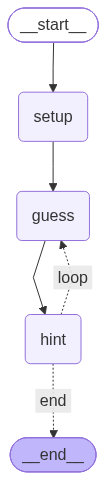

In [52]:
display(Image(graph.get_graph().draw_mermaid_png()))